In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score



In [25]:
df = pd.read_csv("Banglore_traffic_Dataset.csv")
df.head()

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No


In [26]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8936 entries, 0 to 8935
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date                                8936 non-null   object 
 1   Area Name                           8936 non-null   object 
 2   Road/Intersection Name              8936 non-null   object 
 3   Traffic Volume                      8936 non-null   int64  
 4   Average Speed                       8936 non-null   float64
 5   Travel Time Index                   8936 non-null   float64
 6   Congestion Level                    8936 non-null   float64
 7   Road Capacity Utilization           8936 non-null   float64
 8   Incident Reports                    8936 non-null   int64  
 9   Environmental Impact                8936 non-null   float64
 10  Public Transport Usage              8936 non-null   float64
 11  Traffic Signal Compliance           8936 no

In [27]:
df.describe()

,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count
count,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000
mean,29236.048120,39.447427,1.375554,80.818041,92.029215,1.570389,108.472096,45.086651,79.950243,75.155597,114.533348
std,13001.808801,10.707244,0.165319,23.533182,16.583341,1.420047,26.003618,20.208460,11.585006,14.409394,36.812573
min,4233.000000,20.000000,1.000039,5.160279,18.739771,0.000000,58.466000,10.006853,60.003933,50.020411,66.000000
25%,19413.000000,31.775825,1.242459,64.292905,97.354990,0.000000,88.826000,27.341191,69.828270,62.545895,94.000000
50%,27600.000000,39.199368,1.500000,92.389018,100.000000,1.000000,105.200000,45.170684,79.992773,75.317610,102.000000
75%,38058.500000,46.644517,1.500000,100.000000,100.000000,2.000000,126.117000,62.426485,89.957358,87.518589,111.000000
max,72039.000000,89.790843,1.500000,100.000000,100.000000,10.000000,194.078000,79.979744,99.993652,99.995049,243.000000


In [28]:
df.isnull().sum()

Date                                  0
Area Name                             0
Road/Intersection Name                0
Traffic Volume                        0
Average Speed                         0
Travel Time Index                     0
Congestion Level                      0
Road Capacity Utilization             0
Incident Reports                      0
Environmental Impact                  0
Public Transport Usage                0
Traffic Signal Compliance             0
Parking Usage                         0
Pedestrian and Cyclist Count          0
Weather Conditions                    0
Roadwork and Construction Activity    0
dtype: int64

In [29]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
numeric_df.head()

,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count
0,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111
1,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100
2,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189
3,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111
4,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104


In [30]:
features = [
    'Traffic Volume',
    'Average Speed',
    'Travel Time Index',
    'Congestion Level',
    'Road Capacity Utilization'
]
X = df[features]

In [31]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

x_scaled = pd.DataFrame(x_scaled, columns=X.columns)
x_scaled.head()

,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization
0,1.642475,1.007120,0.752807,0.815148,0.480677
1,0.122217,-0.940566,0.752807,0.815148,0.480677
2,-1.679633,1.403518,-2.035479,-2.229745,-3.354921
3,2.433486,0.408175,0.752807,0.815148,0.480677
4,2.157971,0.155916,0.752807,0.815148,0.480677


In [32]:

wcss = []
K_range = range(2, 11)

In [33]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

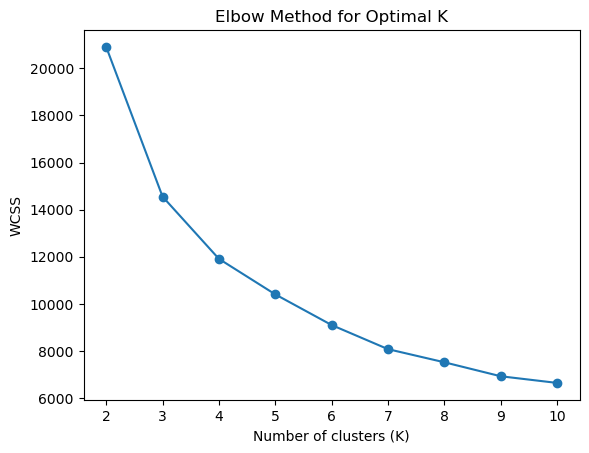

In [34]:
plt.figure()
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

In [35]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(x_scaled)

KMeans(n_clusters=4, random_state=42)

In [36]:
labels = kmeans.labels_


In [37]:
df['Cluster'] = labels


In [38]:
df['Cluster'].value_counts()

Cluster
3    2792
0    2477
2    2261
1    1406
Name: count, dtype: int64

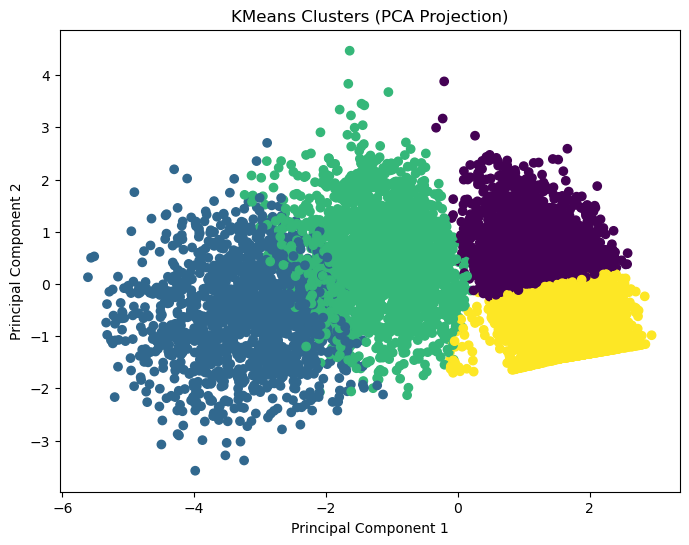

In [48]:
# cluster 3 - sever congestion
# cluster 2 - high congestion
# cluster 1 - moderate congestion
# cluster 0 - low congestion

plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0], x_pca[:,1], c=df['Cluster'])  # KMeans column
plt.title("KMeans Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [42]:
# DBSCAN CLUSTERING 


In [43]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(x_scaled)

df['DBSCAN_Cluster'] = db_labels
df.head()


,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity,Cluster,DBSCAN_Cluster
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No,0,0
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No,3,0
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No,1,1
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No,0,0
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No,0,0


In [44]:
df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    5223
 1    3622
-1      85
 2       6
Name: count, dtype: int64

In [45]:
df[df['DBSCAN_Cluster'] == 2]

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity,Cluster,DBSCAN_Cluster
1518,2022-06-12,M.G. Road,Anil Kumble Circle,14379,21.858360,1.139637,42.775623,73.615587,0,78.758,54.195797,91.162858,88.050131,195,Clear,No,1,2
1711,2022-07-02,Koramangala,Sarjapur Road,14581,20.304462,1.067692,39.484300,69.796255,1,79.162,48.852592,65.856480,59.784459,196,Clear,No,1,2
4315,2023-04-07,Electronic City,Silk Board Junction,14841,25.306147,1.079252,39.724167,72.597694,1,79.682,62.771308,94.426546,55.781152,176,Clear,No,1,2
5897,2023-09-24,Whitefield,ITPL Main Road,14052,21.296139,1.109100,42.714838,72.358253,0,78.104,63.721555,70.292908,70.321712,190,Clear,No,1,2
8299,2024-06-04,Electronic City,Silk Board Junction,14267,20.000000,1.129308,45.633022,67.165069,1,78.534,24.710953,67.179413,51.801700,199,Fog,Yes,1,2
8419,2024-06-16,Jayanagar,South End Circle,15848,20.000000,1.162875,45.537311,76.108549,2,81.696,63.931833,77.490543,67.920780,110,Clear,No,1,2


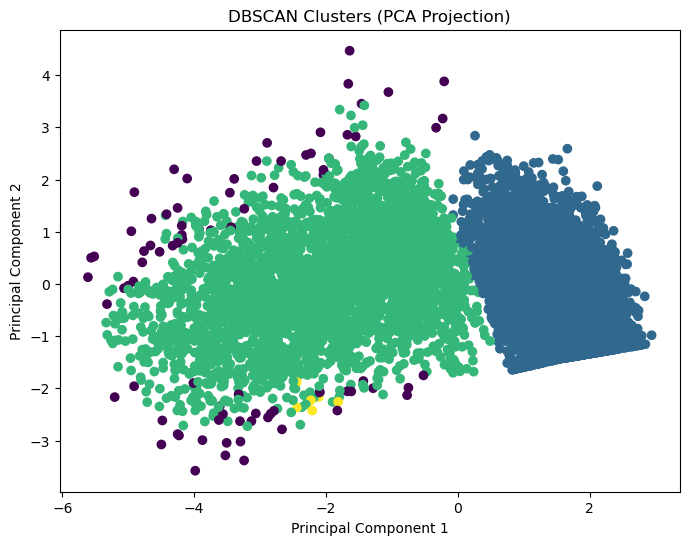

In [46]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0], x_pca[:,1], c=df['DBSCAN_Cluster'])
plt.title("DBSCAN Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


In [47]:

# KMeans score
kmeans_score = silhouette_score(x_scaled, df['Cluster'])
print("KMeans Silhouette Score:", kmeans_score)

# DBSCAN score (exclude noise)
mask = df['DBSCAN_Cluster'] != -1
dbscan_score = silhouette_score(x_scaled[mask], df['DBSCAN_Cluster'][mask])
print("DBSCAN Silhouette Score:", dbscan_score)

KMeans Silhouette Score: 0.333493735325696
DBSCAN Silhouette Score: 0.3941361331704497
